# 25. Live Tutorial 4: Optimization and Mixture Designs

A reduced model isn't the end of a DoE study — it's a map. This session
picks up right where Notebook 24 left off (a trustworthy first-order model
of the adhesive-bonding process) and asks: **which direction do you move
in next?** Then it turns to a design type every previous DoE notebook has
sidestepped: **mixture designs**, for the very common materials-science
situation where your "factors" are ingredient proportions that must sum to
100% — a constraint standard factorial designs simply cannot represent.

**Session plan**
1. A short bridge: from a reduced model to an optimum
2. Mixture designs — the constraint standard DoE ignores
3. Simplex-lattice and simplex-centroid designs, built by hand
4. Fitting a Scheffé mixture model
5. Reading a ternary contour plot

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product, combinations
import statsmodels.formula.api as smf

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
rng = np.random.default_rng(303)

## 25.1 A Short Bridge: From a Reduced Model to an Optimum

Notebooks 19–20 already cover steepest ascent and desirability
optimization in depth — this is a short bridge, not a repeat. Once model
reduction gives you a trustworthy first-order model, **steepest ascent**
moves you toward better settings using nothing more than that model's
coefficients as a direction vector, most useful before you're anywhere
near the optimum (where a first-order model is still a fair local
approximation).

Every notebook in this course runs independently, so the cell below
briefly regenerates Notebook 24 (Live Tutorial 3) §24.2's adhesive-bonding
reduced model from scratch (same seed, same design, same true model) —
see that notebook for the full backward-elimination walkthrough.

In [2]:
# ── Quick setup: regenerate Notebook 24 (Live Tutorial 3) §24.2's reduced model ──
import pyDOE3

design_gen = pyDOE3.fracfact('a b c d abcd')     # 2^(5-1), Resolution V, I=ABCDE
df_adh = pd.DataFrame(design_gen, columns=['A', 'B', 'C', 'D', 'E'])

def true_adhesive_strength(df):
    return (18
            + 4*df.A + 6*df.B + 3*df.C - 2*df.D - 1*df.E
            + 2*df.A*df.B - 1.5*df.C*df.D + 0*df.B*df.C + 0*df.A*df.E)

df_adh['strength_MPa'] = (true_adhesive_strength(df_adh) + rng.normal(0, 1.0, len(df_adh))).round(2)

def backward_elimination(data, response, candidate_terms, alpha=0.05, verbose=False):
    terms = list(candidate_terms)
    while True:
        formula = f'{response} ~ ' + ' + '.join(terms)
        fit = smf.ols(formula, data=data).fit()
        pvalues = fit.pvalues.drop('Intercept')
        worst_term, worst_p = pvalues.idxmax(), pvalues.max()
        if worst_p <= alpha or len(terms) == 1:
            return fit, terms
        terms.remove(worst_term)


candidates = ['A', 'B', 'C', 'D', 'E', 'A:B', 'C:D', 'B:C', 'A:E']
model_reduced, kept_terms = backward_elimination(df_adh, 'strength_MPa', candidates)
print('Reduced model terms:', kept_terms)

Reduced model terms: ['A', 'B', 'C', 'D', 'E', 'A:B', 'C:D']


In [3]:
# Direction of steepest ascent = the reduced model's main-effect coefficients,
# normalised -- literally "move each factor in proportion to how much it helps"
direction = model_reduced.params.reindex(['A', 'B', 'C', 'D', 'E']).fillna(0)
direction_normalized = direction / np.linalg.norm(direction)

print('Steepest-ascent direction (normalised, coded units):')
print(direction_normalized.round(3))

step_size = 0.5   # coded units per step
path = pd.DataFrame([direction_normalized * step_size * i for i in range(6)],
                     columns=direction_normalized.index)
path.index.name = 'step'
print('\nSuggested next experiments along the steepest-ascent path (coded units):')
print(path.round(2))
print('\nRun a few of these, refit, and repeat -- exactly Notebook 20\'s workflow,')
print('until curvature appears (Notebook 22, Live Tutorial 1, Section 22.4\'s test) and it is')
print('time to switch to a full RSM quadratic model (Notebook 19).')

Steepest-ascent direction (normalised, coded units):
A    0.507
B    0.747
C    0.360
D   -0.192
E   -0.134
dtype: float64

Suggested next experiments along the steepest-ascent path (coded units):
         A     B     C     D     E
step                              
0     0.00  0.00  0.00 -0.00 -0.00
1     0.25  0.37  0.18 -0.10 -0.07
2     0.51  0.75  0.36 -0.19 -0.13
3     0.76  1.12  0.54 -0.29 -0.20
4     1.01  1.49  0.72 -0.38 -0.27
5     1.27  1.87  0.90 -0.48 -0.33

Run a few of these, refit, and repeat -- exactly Notebook 20's workflow,
until curvature appears (Notebook 22, Live Tutorial 1, Section 22.4's test) and it is
time to switch to a full RSM quadratic model (Notebook 19).


## 25.2 Mixture Designs: The Constraint Standard DoE Ignores

Every design so far — factorial, fractional, RSM — assumed factors can be
set **independently**: cranking up temperature does not force pressure to
change. Formulation problems break that assumption completely. Blend three
solvents for a battery electrolyte and their volume fractions **must sum
to 100%** — increase one, and at least one other necessarily decreases.
Run a standard $2^3$ factorial on volume fractions and roughly half the
design points describe physically impossible mixtures (fractions above
1, or summing to nonsense).

The feasible region for $q$ components is not a cube — it's the
**simplex**: for 3 components, a triangle; for 4, a tetrahedron. A
**mixture design** places runs *within* that constrained region instead of
a cube's corners.

## 25.3 Simplex-Lattice and Simplex-Centroid Designs, Built by Hand

A $\{q,m\}$ **simplex-lattice design** takes every combination of $q$
components at $m{+}1$ evenly spaced levels ($0, 1/m, 2/m, \ldots, 1$) whose
proportions sum to exactly 1. For $q=3,\ m=2$: levels $\{0, 0.5, 1\}$,
giving the 3 pure-component vertices plus the 3 binary-blend edge
midpoints — 6 points total, and every one of them a physically realisable
blend by construction.

In [4]:
def simplex_lattice(q, m):
    """All q-component blends at levels {0, 1/m, ..., 1} that sum to 1."""
    levels = [i / m for i in range(m + 1)]
    return np.array([combo for combo in product(levels, repeat=q) if np.isclose(sum(combo), 1.0)])

def simplex_centroid(q):
    """The centroid of every non-empty subset of q components (2^q - 1 points)."""
    points = []
    for r in range(1, q + 1):
        for subset in combinations(range(q), r):
            point = np.zeros(q)
            point[list(subset)] = 1.0 / r
            points.append(point)
    return np.array(points)


lattice_32 = simplex_lattice(q=3, m=2)
centroid_3 = simplex_centroid(q=3)
print(f'{3,2} simplex-lattice design ({len(lattice_32)} points):')
print(pd.DataFrame(lattice_32, columns=['EC', 'EMC', 'DMC']))
print(f'\nSimplex-centroid design ({len(centroid_3)} points) includes the same vertices/edges')
print('plus the overall centroid (1/3, 1/3, 1/3):')
print(pd.DataFrame(centroid_3, columns=['EC', 'EMC', 'DMC']).round(3))

(3, 2) simplex-lattice design (6 points):
    EC  EMC  DMC
0  0.0  0.0  1.0
1  0.0  0.5  0.5
2  0.0  1.0  0.0
3  0.5  0.0  0.5
4  0.5  0.5  0.0
5  1.0  0.0  0.0

Simplex-centroid design (7 points) includes the same vertices/edges
plus the overall centroid (1/3, 1/3, 1/3):
      EC    EMC    DMC
0  1.000  0.000  0.000
1  0.000  1.000  0.000
2  0.000  0.000  1.000
3  0.500  0.500  0.000
4  0.500  0.000  0.500
5  0.000  0.500  0.500
6  0.333  0.333  0.333


## 25.4 Fitting a Scheffé Mixture Model

**Electrolyte solvent blend study**: three carbonate solvents — **EC**
(ethylene carbonate), **EMC** (ethyl methyl carbonate), **DMC** (dimethyl
carbonate) — blended in varying proportions, response = ionic conductivity
(mS/cm). We combine the lattice and centroid designs above, **replicate
the centroid 3 times** (the mixture-design equivalent of Notebook 22 (Live
Tutorial 1) §22.4's centre-point replication, for a pure-error / lack-of-fit
check), and fit a **Scheffé quadratic model**:

$$y = \sum_i \beta_i x_i + \sum_{i<j} \beta_{ij}\, x_i x_j$$

Notice there is **no intercept term**. Because $x_1+x_2+x_3=1$ always,
an intercept would be perfectly collinear with the three linear terms —
the regression matrix would be singular. Dropping the intercept
(`-1` in the formula) is not a stylistic choice here; it is required for
the model to be fittable at all, and is the single most important
scripting detail that differs from every other regression in this
course.

In [5]:
mixture_points = np.vstack([lattice_32, np.tile([1/3, 1/3, 1/3], (3, 1))])   # + 3 centroid replicates
df_mix = pd.DataFrame(mixture_points, columns=['EC', 'EMC', 'DMC'])

# True Scheffe model: pure-component conductivities + interaction (blending) terms.
# Positive interaction terms model the real, well-documented phenomenon that binary
# carbonate-solvent blends often conduct better than a linear blend of the pure
# components would predict (a genuine synergy, not just illustrative convenience).
b = {'EC': 3.0, 'EMC': 5.5, 'DMC': 6.0, 'EC:EMC': 4.0, 'EC:DMC': 3.0, 'EMC:DMC': -1.0}
true_cond = (b['EC']*df_mix.EC + b['EMC']*df_mix.EMC + b['DMC']*df_mix.DMC
             + b['EC:EMC']*df_mix.EC*df_mix.EMC + b['EC:DMC']*df_mix.EC*df_mix.DMC
             + b['EMC:DMC']*df_mix.EMC*df_mix.DMC)
df_mix['conductivity_mS_cm'] = (true_cond + rng.normal(0, 0.15, len(df_mix))).round(3)
print(df_mix)

         EC       EMC       DMC  conductivity_mS_cm
0  0.000000  0.000000  1.000000               5.534
1  0.000000  0.500000  0.500000               5.596
2  0.000000  1.000000  0.000000               5.596
3  0.500000  0.000000  0.500000               5.242
4  0.500000  0.500000  0.000000               5.251
5  1.000000  0.000000  0.000000               3.177
6  0.333333  0.333333  0.333333               5.255
7  0.333333  0.333333  0.333333               5.496
8  0.333333  0.333333  0.333333               5.775


In [6]:
model_mix = smf.ols('conductivity_mS_cm ~ EC + EMC + DMC '
                     '+ EC:EMC + EC:DMC + EMC:DMC - 1', data=df_mix).fit()
print(model_mix.summary().tables[1])

# Lack-of-fit check using the 3 replicated centroid points,
# same F-test logic as Notebook 22 (Live Tutorial 1) §22.4
centroid_reps = df_mix.iloc[-3:]
pure_error_var = centroid_reps['conductivity_mS_cm'].var(ddof=1)
centroid_pred = model_mix.predict(centroid_reps).iloc[0]
print(f"\nCentroid replicates: {centroid_reps['conductivity_mS_cm'].values}")
print(f'Pure-error std at centroid: {np.sqrt(pure_error_var):.3f} mS/cm')
print(f'Model prediction at centroid: {centroid_pred:.3f} mS/cm')

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
EC             3.1830      0.213     14.922      0.001       2.504       3.862
EMC            5.6020      0.213     26.262      0.000       4.923       6.281
DMC            5.5400      0.213     25.971      0.000       4.861       6.219
EC:EMC         3.3372      0.933      3.578      0.037       0.369       6.305
EC:DMC         3.4252      0.933      3.672      0.035       0.457       6.393
EMC:DMC        0.0032      0.933      0.003      0.997      -2.965       2.971

Centroid replicates: [5.255 5.496 5.775]
Pure-error std at centroid: 0.260 mS/cm
Model prediction at centroid: 5.527 mS/cm


:::{admonition} Take-home message
:class: tip

- The three linear (pure-component) coefficients land close to their true values — EC 3.18 (true 3.0), EMC 5.60 (true 5.5) — but DMC comes out at 5.54 against a true value of 6.0, a bigger miss than the noise level (σ=0.15) alone would suggest is typical. That is a direct consequence of design size: each pure-vertex coefficient here is pinned down by essentially **one** unreplicated run at that vertex, so a single unlucky noisy measurement shifts the fitted coefficient directly — exactly why real mixture studies often replicate every design point, not only the centroid.
- `EMC:DMC`'s fitted coefficient (0.003, p=0.997) completely misses its true value of −1.0, while `EC:EMC` (3.34) and `EC:DMC` (3.43) both land in the right neighbourhood of their true values (4.0 and 3.0). With only 9 runs fitting 6 parameters, this design has very little spare information to pin down every interaction precisely — a useful reminder that a high R²-style fit to the data you have doesn't guarantee every individual coefficient is well estimated, especially the smaller ones.
:::

**Checkpoint**: compare each fitted coefficient to the `b` dictionary used
to generate the data. The three linear terms should recover the pure
component conductivities (EC≈3.0, EMC≈5.5, DMC≈6.0 mS/cm) directly — a
distinctive, convenient feature of the Scheffé parameterisation: unlike an
ordinary regression intercept, **each linear coefficient here is literally
the model's predicted response for the pure component itself**
($x_i=1$, everything else 0).

## 25.5 Reading a Ternary Contour Plot

A 3-component mixture's response surface lives naturally on a **triangle**
(each corner a pure component), not a rectangle — matplotlib has no
built-in ternary axis, but the barycentric-to-Cartesian transform is two
lines of trigonometry, and `tricontourf` handles the rest.

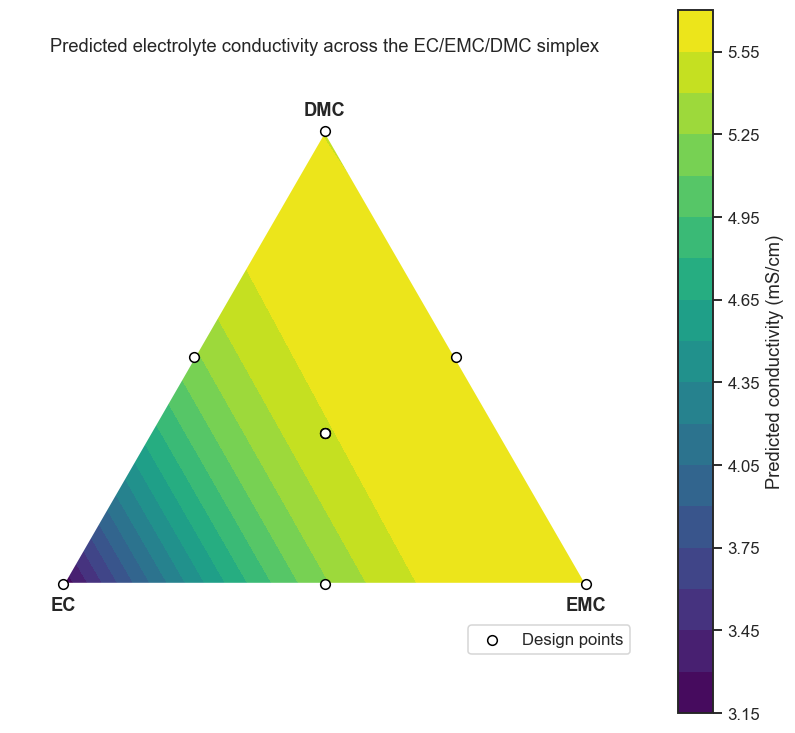

Predicted best blend: EC=0.15, EMC=0.85, DMC=0.00 -> 5.66 mS/cm


In [7]:
def ternary_to_cartesian(x1, x2, x3):
    """EC(x1) at (0,0), EMC(x2) at (1,0), DMC(x3) at (0.5, sqrt(3)/2)."""
    X = x2 + 0.5 * x3
    Y = (np.sqrt(3) / 2) * x3
    return X, Y

# A fine grid covering the whole simplex, for a smooth contour fill
grid_pts = simplex_lattice(q=3, m=40)     # 40 -> 861 points, plenty for a smooth contour
grid_df = pd.DataFrame(grid_pts, columns=['EC', 'EMC', 'DMC'])
grid_df['pred'] = model_mix.predict(grid_df)
gx, gy = ternary_to_cartesian(grid_df.EC, grid_df.EMC, grid_df.DMC)

fig, ax = plt.subplots(figsize=(7.5, 6.8))
contour = ax.tricontourf(gx, gy, grid_df['pred'], levels=20, cmap='viridis')
plt.colorbar(contour, ax=ax, label='Predicted conductivity (mS/cm)')

# Triangle outline and vertex labels
triangle = plt.Polygon([(0, 0), (1, 0), (0.5, np.sqrt(3)/2)], fill=False, edgecolor='white', lw=1.5)
ax.add_patch(triangle)
for label, (vx, vy) in zip(['EC', 'EMC', 'DMC'], [(0, -0.05), (1, -0.05), (0.5, np.sqrt(3)/2 + 0.03)]):
    ax.text(vx, vy, label, ha='center', fontsize=12, fontweight='bold')

# Overlay the actual design points used to fit the model
dx, dy = ternary_to_cartesian(df_mix.EC, df_mix.EMC, df_mix.DMC)
ax.scatter(dx, dy, color='white', edgecolor='black', s=40, zorder=5, label='Design points')

ax.set_xlim(-0.1, 1.1); ax.set_ylim(-0.15, 1.0)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Predicted electrolyte conductivity across the EC/EMC/DMC simplex')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

best_idx = grid_df['pred'].idxmax()
print(f"Predicted best blend: EC={grid_df.loc[best_idx,'EC']:.2f}, "
      f"EMC={grid_df.loc[best_idx,'EMC']:.2f}, DMC={grid_df.loc[best_idx,'DMC']:.2f} "
      f"-> {grid_df.loc[best_idx,'pred']:.2f} mS/cm")

:::{admonition} Take-home message
:class: tip

- The predicted best blend (EC=0.15, EMC=0.85, DMC=0.00) sits on the EC–EMC edge, not at any single pure vertex — exactly the "interior or edge point wins" result the checkpoint below predicts. It isn't obvious from the pure-component values alone: EC's own fitted conductivity (3.18 mS/cm) is actually the *lowest* of the three, well below EMC's (5.60) and DMC's (5.54) — the blend keeps 15% EC not because EC performs well on its own, but because the strong positive `EC:EMC` interaction (+3.34) means blending some EC into EMC pushes conductivity *above* what EMC alone achieves. That is a genuine synergy, not a compromise between two similar pure components.
- Notice `EC:DMC`'s fitted interaction (3.425) is actually *slightly larger* than `EC:EMC`'s (3.337) — by the interaction coefficient alone, you might expect the EC–DMC edge to win instead. It doesn't, because EMC's own pure-component conductivity (5.60) beats DMC's (5.54) by a hair: the winning edge is a combination of a strong interaction *and* a good baseline, not either one read in isolation.
- The bright region hugs the whole EC–EMC edge rather than sitting at one sharp point — several nearby blends perform almost as well as the single reported optimum, which matters in practice: hitting a blend ratio to three decimal places on the bench is rarely realistic, and this plot shows you don't need to.
:::

**Checkpoint**: read off the "Predicted best blend" printed above — it
should **not** be any single pure vertex, and it should sit on whichever
edge connects the two components with the strongest positive interaction
coefficient in Section 25.4's fitted model (compare `EC:EMC` and `EC:DMC`
to decide which edge that should be, then check the printed proportions
against your prediction). This is precisely why mixture experiments are
worth running at all: the best blend is very often an interior or edge
point that no amount of testing pure components alone could ever
reveal.

---
## Exercises

**Core practice**

1. **A 4-component mixture**: Add a fourth solvent, **FEC**, to the
   electrolyte study (assign it plausible pure-component conductivity and
   at least one interaction term). Generate a $\{4,2\}$ simplex-lattice
   design with `simplex_lattice(q=4, m=2)` — how many design points does it
   produce, and how does that compare to a $2^4$ full factorial's 16 runs?

2. **Constrained mixture**: In practice, a real formulation often can't use
   the full simplex — e.g. EC must be present between 20% and 40% (pure EC
   at room temperature is a solid, and pure carbonate-free blends have
   poor Li⁺ solvation). Filter `simplex_lattice(q=3, m=10)` to only the
   points satisfying `0.2 <= EC <= 0.4`, and note how this reshapes the
   feasible region — this smaller shape is what real "constrained mixture
   designs" (D-optimal, beyond this course) are built to cover efficiently.

**Deeper practice**

3. **Special cubic model**: Extend Section 25.4's model formula with a
   three-way mixture term, `EC:EMC:DMC` (the mixture analogue of a 3-factor
   interaction — called the "special cubic" term in mixture-design
   terminology). Refit and check whether it's significant with only 9 design
   points; if the model is now nearly saturated, explain in one sentence
   why a real special-cubic study would need a larger design (hint: how
   many *additional* interior points would a $\{3,3\}$ simplex-lattice
   design provide beyond $\{3,2\}$?).

4. **Optimize under a lower bound**: Using Section 25.5's fitted model,
   search only the portion of `grid_df` satisfying `EC >= 0.15` (representing
   a practical minimum EC needed for adequate low-temperature performance,
   a genuine real electrolyte design trade-off) for the best blend. How
   much conductivity is given up compared to the unconstrained optimum
   found in Section 25.5?

5. **Steepest ascent, followed through**: Using Section 25.1's path,
   simulate a response at each suggested step with the true model
   regenerated in Section 25.1 (extended to keep going indefinitely, e.g.
   flattening out automatically past $x=\pm1$ to represent a real process
   limit), and determine after how many steps the curvature test from
   Notebook 22 (Live Tutorial 1) §22.4 would trigger — i.e., when steepest
   ascent should stop and an RSM study (Notebook 19) should begin.

6. **Your own mixture study**: Pick a materials system with a genuine
   proportion constraint — a glass composition (SiO₂/Na₂O/CaO), a metal
   alloy, a polymer blend, a ceramic slurry — and build a $\{3,2\}$
   simplex-lattice or simplex-centroid design for it, following Sections
   25.3–25.5 end to end with your own plausible pure-component values and at
   least one synergy or antagonism term.